<a href="https://colab.research.google.com/github/rhmau1/PCVK_26/blob/main/Modul5/Modul5_E2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

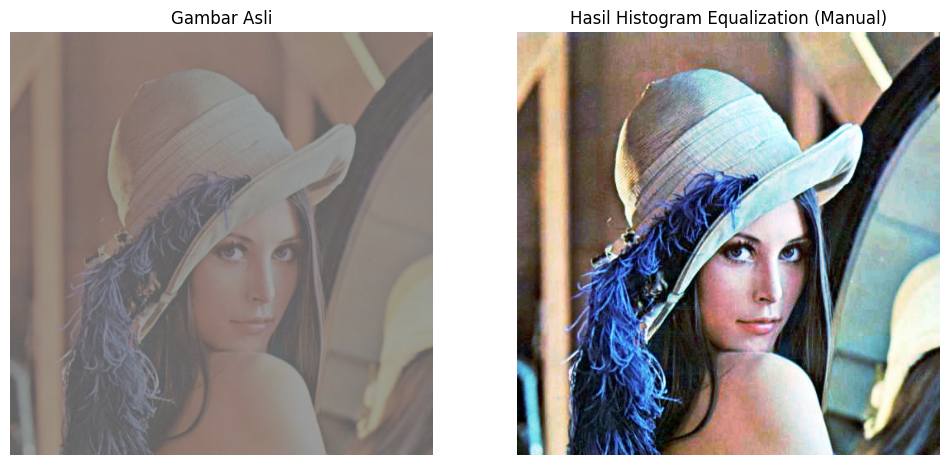

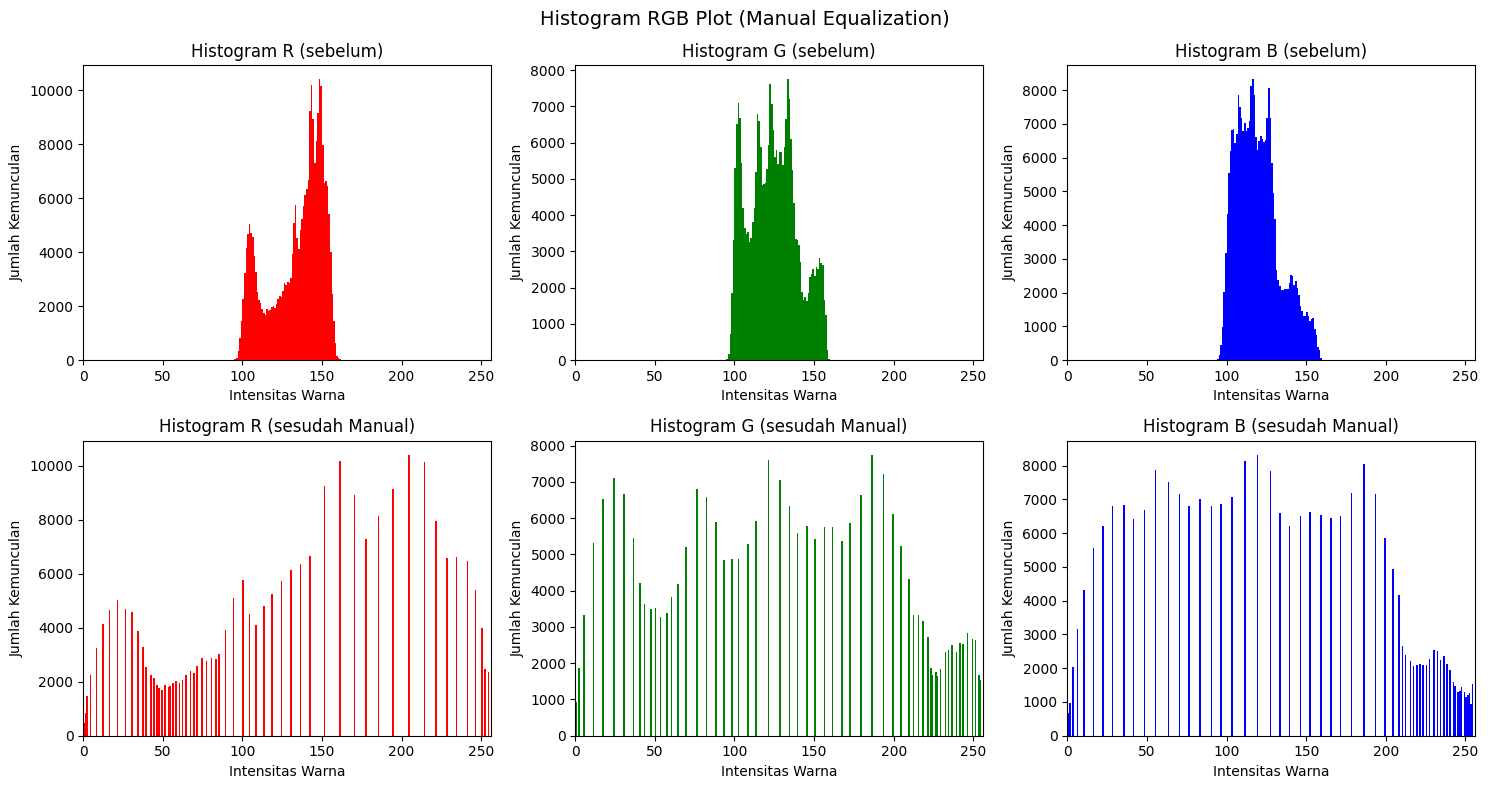

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
image = cv2.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/lena_lc.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Pisahkan channel RGB asli
r_orig, g_orig, b_orig = cv2.split(image_rgb)

def manual_equalize(channel):
    hist, bins = np.histogram(channel.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_final = cdf_normalized.astype('uint8')
    img_eq = cdf_final[channel]
    return img_eq

# Manual Equalization
r_eq = manual_equalize(r_orig)
g_eq = manual_equalize(g_orig)
b_eq = manual_equalize(b_orig)

img_eq_manual = cv2.merge((r_eq, g_eq, b_eq))

# Tampilkan gambar asli dan hasil equalization (Manual)
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq_manual)
plt.title("Hasil Histogram Equalization (Manual)")
plt.axis("off")

plt.show()

# Plot histogram sebelum dan sesudah (Manual)
fig, axes = plt.subplots(2, 3, figsize=(15,8))

axes[0,0].hist(r_orig.flatten(), bins=256, range=[0,256], color='r')
axes[0,0].set_title("Histogram R (sebelum)")

axes[0,1].hist(g_orig.flatten(), bins=256, range=[0,256], color='g')
axes[0,1].set_title("Histogram G (sebelum)")

axes[0,2].hist(b_orig.flatten(), bins=256, range=[0,256], color='b')
axes[0,2].set_title("Histogram B (sebelum)")


axes[1,0].hist(r_eq.flatten(), bins=256, range=[0,256], color='r')
axes[1,0].set_title("Histogram R (sesudah Manual)")

axes[1,1].hist(g_eq.flatten(), bins=256, range=[0,256], color='g')
axes[1,1].set_title("Histogram G (sesudah Manual)")

axes[1,2].hist(b_eq.flatten(), bins=256, range=[0,256], color='b')
axes[1,2].set_title("Histogram B (sesudah Manual)")

for ax in axes.flat:
    ax.set_xlim([0,256])
    ax.set_xlabel("Intensitas Warna")
    ax.set_ylabel("Jumlah Kemunculan")

plt.suptitle("Histogram RGB Plot (Manual Equalization)", fontsize=14)
plt.tight_layout()
plt.show()

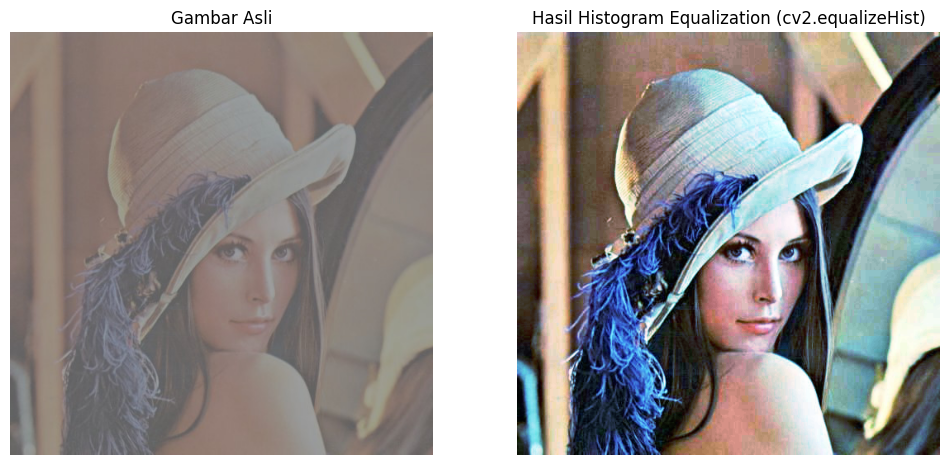

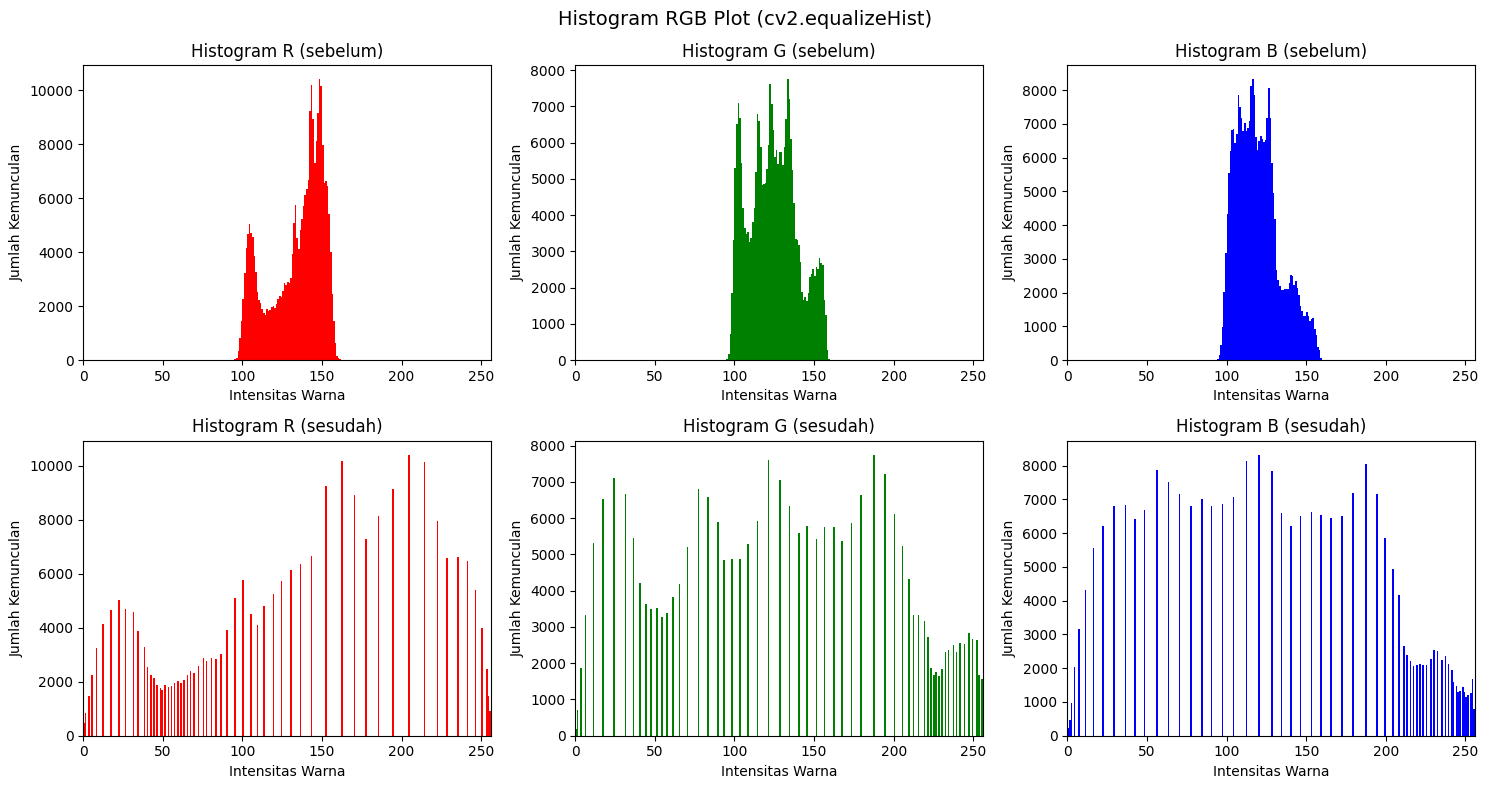

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
image = cv2.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/lena_lc.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Pisahkan channel RGB
r_orig, g_orig, b_orig = cv2.split(image_rgb)

# Equalization dengan fungsi bawaan OpenCV
r_eq_cv2 = cv2.equalizeHist(r_orig)
g_eq_cv2 = cv2.equalizeHist(g_orig)
b_eq_cv2 = cv2.equalizeHist(b_orig)

# Gabungkan kembali (RGB)
img_eq_cv2_rgb = cv2.merge((r_eq_cv2, g_eq_cv2, b_eq_cv2))

# Tampilkan gambar asli dan hasil equalization
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq_cv2_rgb)
plt.title("Hasil Histogram Equalization (cv2.equalizeHist)")
plt.axis("off")

plt.show()

# Plot histogram sebelum dan sesudah
fig, axes = plt.subplots(2, 3, figsize=(15,8))

axes[0,0].hist(r_orig.flatten(), bins=256, range=[0,256], color='r')
axes[0,0].set_title("Histogram R (sebelum)")

axes[0,1].hist(g_orig.flatten(), bins=256, range=[0,256], color='g')
axes[0,1].set_title("Histogram G (sebelum)")

axes[0,2].hist(b_orig.flatten(), bins=256, range=[0,256], color='b')
axes[0,2].set_title("Histogram B (sebelum)")


axes[1,0].hist(r_eq_cv2.flatten(), bins=256, range=[0,256], color='r')
axes[1,0].set_title("Histogram R (sesudah)")

axes[1,1].hist(g_eq_cv2.flatten(), bins=256, range=[0,256], color='g')
axes[1,1].set_title("Histogram G (sesudah)")

axes[1,2].hist(b_eq_cv2.flatten(), bins=256, range=[0,256], color='b')
axes[1,2].set_title("Histogram B (sesudah)")

for ax in axes.flat:
    ax.set_xlim([0,256])
    ax.set_xlabel("Intensitas Warna")
    ax.set_ylabel("Jumlah Kemunculan")

plt.suptitle("Histogram RGB Plot (cv2.equalizeHist)", fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
# Menghitung selisih absolut maksimum per channel
diff_r = np.abs(r_eq.astype(int) - r_eq_cv2.astype(int)).max()
diff_g = np.abs(g_eq.astype(int) - g_eq_cv2.astype(int)).max()
diff_b = np.abs(b_eq.astype(int) - b_eq_cv2.astype(int)).max()

print(f"Selisih maksimal R: {diff_r}")
print(f"Selisih maksimal G: {diff_g}")
print(f"Selisih maksimal B: {diff_b}")

Selisih maksimal R: 1
Selisih maksimal G: 1
Selisih maksimal B: 1


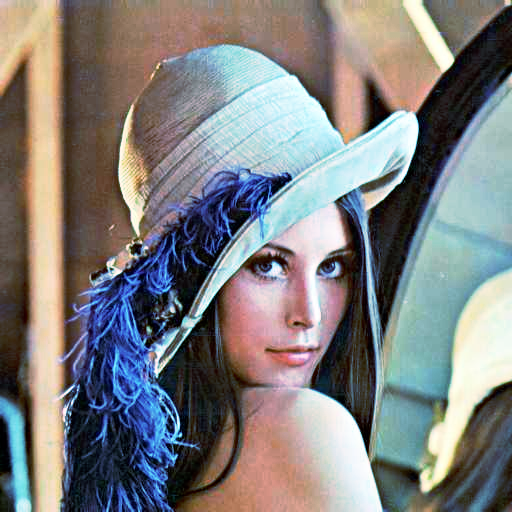

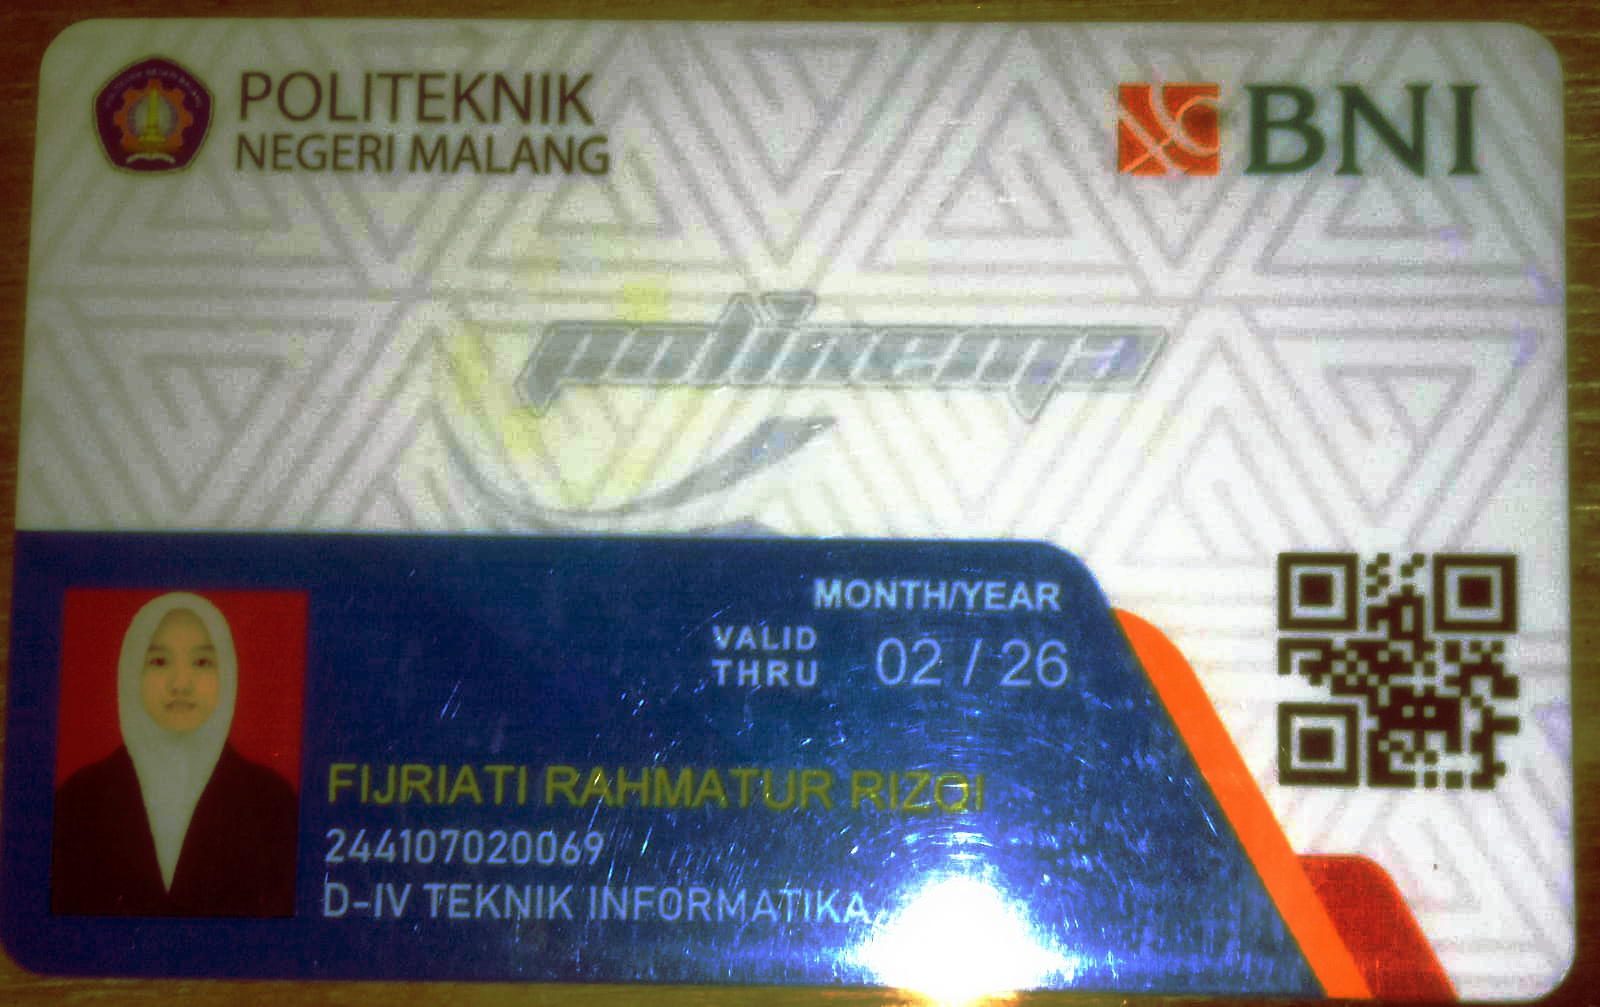

In [37]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
berkas = '/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/lena.jpg'
bgr = cv.imread(berkas)
# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
  kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)
cv2_imshow(he_rgb)


berkas2 = '/content/drive/MyDrive/TI 3C RESOURCES /PCVK/KTM-1C.jpeg'
bgr2 = cv.imread(berkas2)
# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr2))
for i in range(3):
  kanal[i] = cv.equalizeHist(kanal[i])
he_rgb2 = cv.merge(kanal)
cv2_imshow(he_rgb2)

In [41]:
# cara 2: hanya kanal terang yang diekualisasi
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# varian setara pada ruang warna lain
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

In [45]:
# cara 2: hanya kanal terang yang diekualisasi
ycrcb_ktm = cv.cvtColor(bgr2, cv.COLOR_BGR2YCrCb)
y_ktm, cr_ktm, cb_ktm = cv.split(ycrcb_ktm)
he_y_ktm = cv.cvtColor(cv.merge([cv.equalizeHist(y_ktm), cr_ktm, cb_ktm]), cv.COLOR_YCrCb2BGR)

# varian setara pada ruang warna lain
hsv_ktm = cv.cvtColor(bgr2, cv.COLOR_BGR2HSV)
h_ktm, sat_ktm, v_ktm = cv.split(hsv_ktm)
he_v_ktm = cv.cvtColor(cv.merge([h_ktm, sat_ktm, cv.equalizeHist(v_ktm)]), cv.COLOR_HSV2BGR)

lab_ktm = cv.cvtColor(bgr2, cv.COLOR_BGR2LAB)
l_ktm, a_ktm, b_ktm = cv.split(lab_ktm)
he_l_ktm = cv.cvtColor(cv.merge([cv.equalizeHist(l_ktm), a_ktm, b_ktm]), cv.COLOR_LAB2BGR)

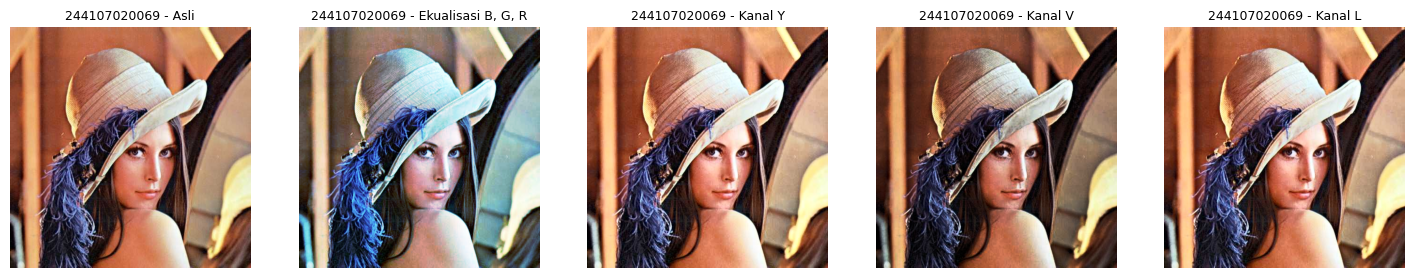

In [43]:
NIM = '244107020069'

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]
plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

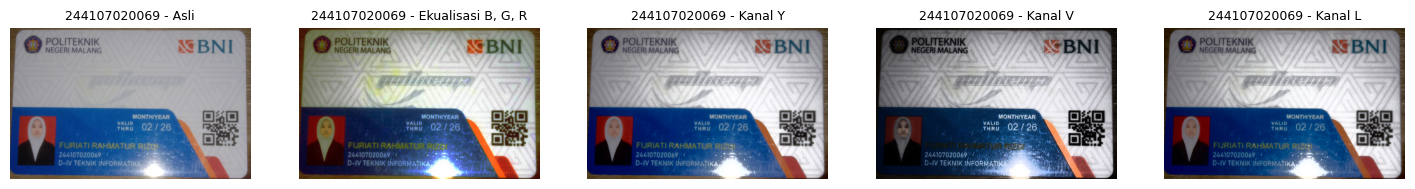

In [46]:
NIM = '244107020069'

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr2, he_rgb2, he_y_ktm, he_v_ktm, he_l_ktm]
plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

In [44]:
def geser_hue(asli, hasil):
   h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
   h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
   d = np.abs(h1 - h2)
   d = np.minimum(d, 180 - d) # Hue melingkar 0-179
   return d.mean()
print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
 print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            122.2
Ekualisasi B, G, R                53.03            127.4
Kanal Y                            0.40            127.9
Kanal V                            0.87            100.6
Kanal L                            1.65            122.7


In [47]:
def geser_hue(asli, hasil):
   h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
   h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
   d = np.abs(h1 - h2)
   d = np.minimum(d, 180 - d) # Hue melingkar 0-179
   return d.mean()
print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
 print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr2, c) * 2,
cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            128.3
Ekualisasi B, G, R                71.14            129.0
Kanal Y                            1.30            129.8
Kanal V                            2.90            113.9
Kanal L                            7.89            123.1


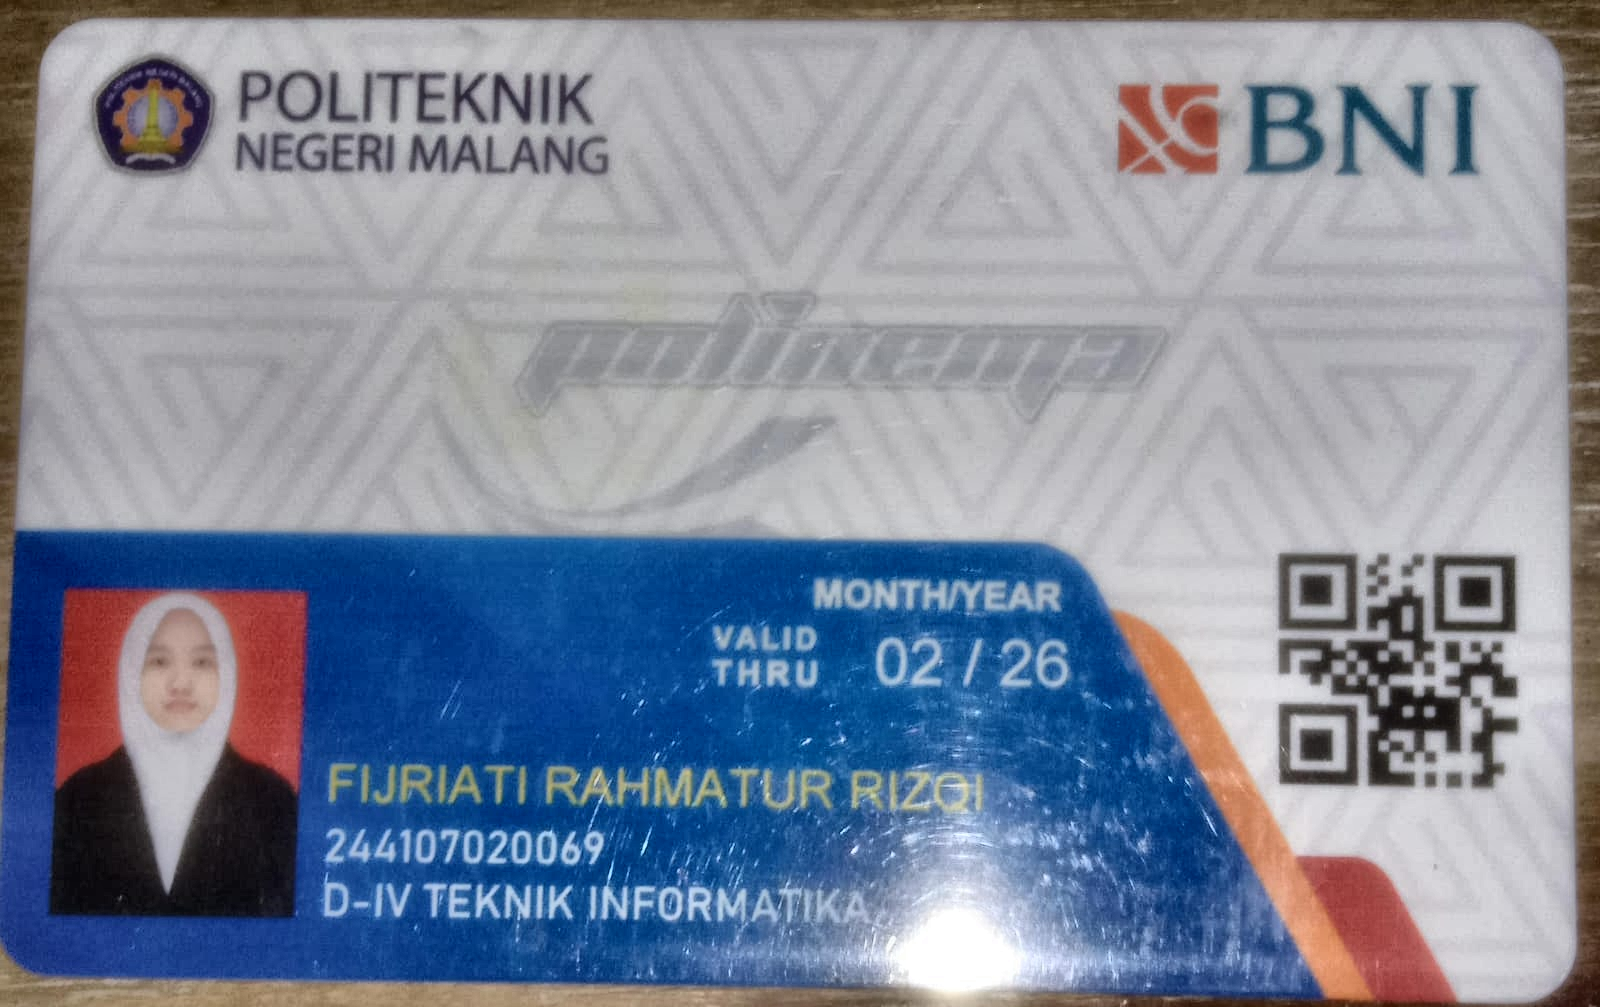

In [51]:
import cv2 as cv

# 1. Konversi ke YCrCb
img_yuv = cv.cvtColor(bgr2, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(img_yuv)

# 2. Terapkan CLAHE pada kanal terang (Y)
PARAM = {'clip': 2.0, 'tile': 8}
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
y_clahe = clahe.apply(y)

# 3. Gabungkan dan kembalikan ke BGR
img_yuv_clahe = cv.merge((y_clahe, cr, cb))
hasil_clahe = cv.cvtColor(img_yuv_clahe, cv.COLOR_YCrCb2BGR)
cv2_imshow(hasil_clahe)

In [54]:
judul2 =[ 'clahe']
citra2 = [hasil_clahe]
def geser_hue(asli, hasil):
   h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
   h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
   d = np.abs(h1 - h2)
   d = np.minimum(d, 180 - d) # Hue melingkar 0-179
   return d.mean()
print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul2, citra2):
 print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr2, c) * 2,
cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
clahe                              0.07            136.5


PSNR (Asli vs Manual) : 9.73 dB
PSNR (Asli vs OpenCV) : 9.73 dB


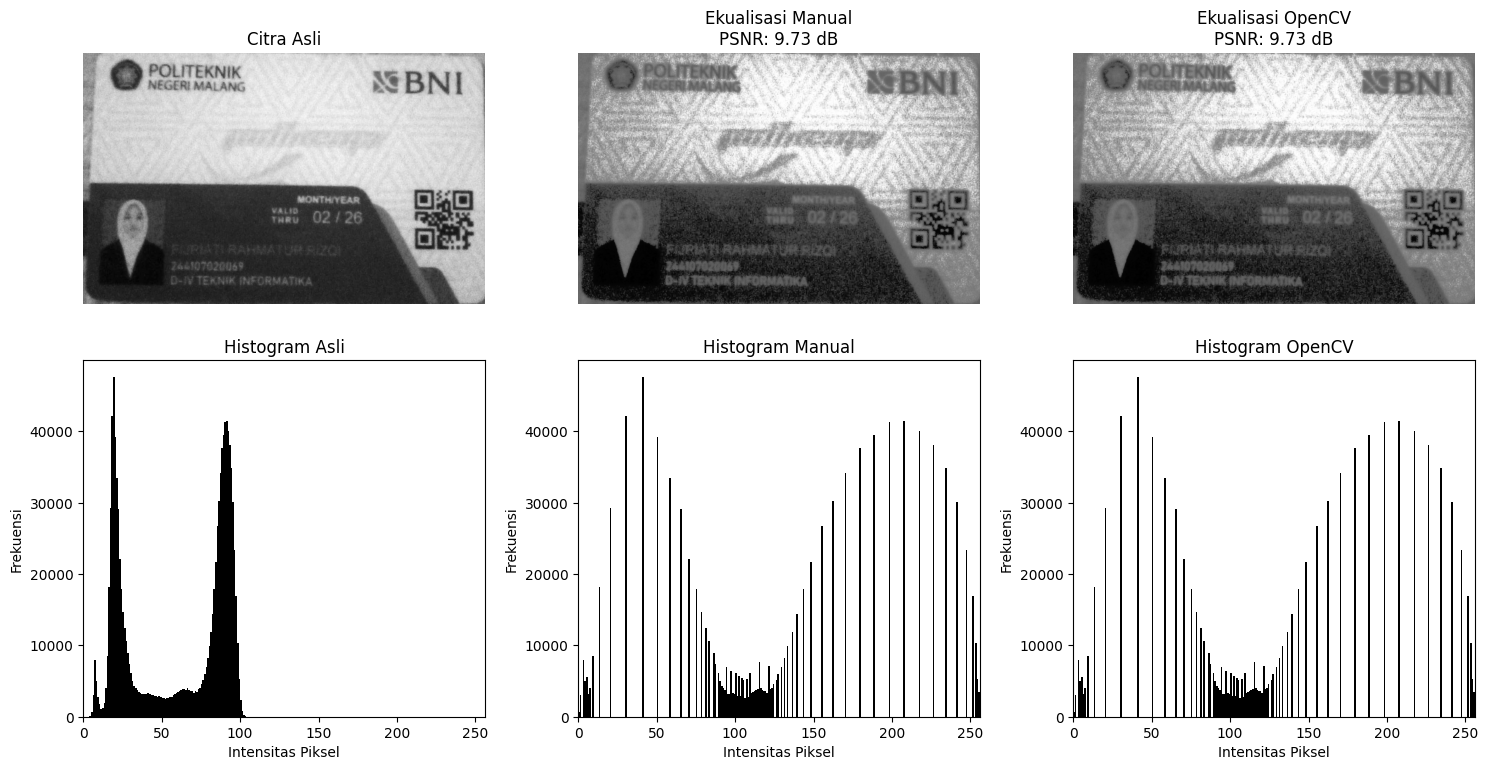

In [55]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi grayscale
# 1. Baca citra dalam format grayscale
img_asli = cv.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/KTM-1A.jpeg', cv.IMREAD_GRAYSCALE)

if img_asli is None:
    print("Error: Gambar 'KTM1a.jpg' tidak ditemukan. Pastikan path benar.")
else:
    # 2. Implementasi Ekualisasi Manual
    hist_manual, bins = np.histogram(img_asli.flatten(), 256, [0,256])
    cdf = hist_manual.cumsum()
    # Mengabaikan nilai 0 dalam pencarian nilai minimum CDF
    cdf_min = cdf[cdf > 0].min()

    # Normalisasi CDF
    cdf_normalized = (cdf - cdf_min) * 255 / (cdf.max() - cdf_min)
    cdf_final = np.round(cdf_normalized).astype('uint8')
    img_manual = cdf_final[img_asli]

    # 3. Implementasi Ekualisasi OpenCV
    img_cv = cv.equalizeHist(img_asli)

    # c. Hitung PSNR antara citra asli dan citra hasil ekualisasi
    psnr_manual = cv.PSNR(img_asli, img_manual)
    psnr_cv = cv.PSNR(img_asli, img_cv)

    print(f"PSNR (Asli vs Manual) : {psnr_manual:.2f} dB")
    print(f"PSNR (Asli vs OpenCV) : {psnr_cv:.2f} dB")

    # b. Tampilkan citra asli, hasil ekualisasi, serta histogram dalam satu layout
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # Baris 1: Citra
    axes[0, 0].imshow(img_asli, cmap='gray')
    axes[0, 0].set_title("Citra Asli")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img_manual, cmap='gray')
    axes[0, 1].set_title(f"Ekualisasi Manual\nPSNR: {psnr_manual:.2f} dB")
    axes[0, 1].axis('off')

    axes[0, 2].imshow(img_cv, cmap='gray')
    axes[0, 2].set_title(f"Ekualisasi OpenCV\nPSNR: {psnr_cv:.2f} dB")
    axes[0, 2].axis('off')

    # Baris 2: Histogram
    axes[1, 0].hist(img_asli.flatten(), bins=256, range=[0, 256], color='black')
    axes[1, 0].set_title("Histogram Asli")

    axes[1, 1].hist(img_manual.flatten(), bins=256, range=[0, 256], color='black')
    axes[1, 1].set_title("Histogram Manual")

    axes[1, 2].hist(img_cv.flatten(), bins=256, range=[0, 256], color='black')
    axes[1, 2].set_title("Histogram OpenCV")

    for ax in axes[1, :]:
        ax.set_xlim([0, 256])
        ax.set_xlabel("Intensitas Piksel")
        ax.set_ylabel("Frekuensi")

    plt.tight_layout()
    plt.show()

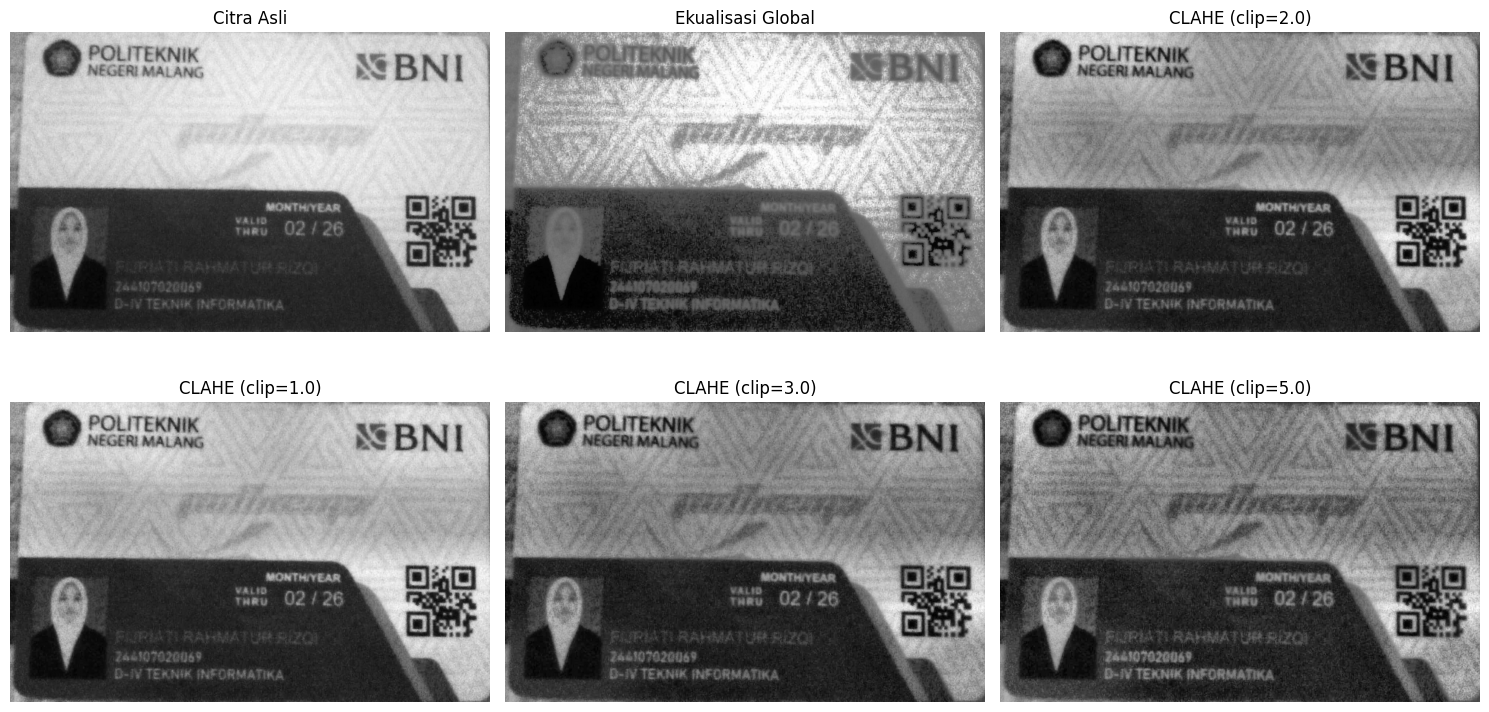

In [56]:
import cv2 as cv
import matplotlib.pyplot as plt

# Membaca citra grayscale (Ganti path sesuai lokasi file Anda)
img_ktm = cv.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/KTM-1A.jpeg', cv.IMREAD_GRAYSCALE)

if img_ktm is not None:
    # a. Ekualisasi Global vs CLAHE
    img_global = cv.equalizeHist(img_ktm)

    PARAM = {'clip': 2.0, 'tile': 8}
    clahe_base = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
    img_clahe_base = clahe_base.apply(img_ktm)

    # b. Variasi tiga nilai clipLimit di sekitar nilai awal (misal: 1.0, 3.0, 5.0)
    clips = [1.0, 3.0, 5.0]
    clahe_results = []
    for c in clips:
        clahe = cv.createCLAHE(clipLimit=c, tileGridSize=(PARAM['tile'], PARAM['tile']))
        clahe_results.append(clahe.apply(img_ktm))

    # Plotting hasil
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    axes[0, 0].imshow(img_ktm, cmap='gray')
    axes[0, 0].set_title("Citra Asli")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img_global, cmap='gray')
    axes[0, 1].set_title("Ekualisasi Global")
    axes[0, 1].axis('off')

    axes[0, 2].imshow(img_clahe_base, cmap='gray')
    axes[0, 2].set_title(f"CLAHE (clip={PARAM['clip']})")
    axes[0, 2].axis('off')

    axes[1, 0].imshow(clahe_results[0], cmap='gray')
    axes[1, 0].set_title(f"CLAHE (clip={clips[0]})")
    axes[1, 0].axis('off')

    axes[1, 1].imshow(clahe_results[1], cmap='gray')
    axes[1, 1].set_title(f"CLAHE (clip={clips[1]})")
    axes[1, 1].axis('off')

    axes[1, 2].imshow(clahe_results[2], cmap='gray')
    axes[1, 2].set_title(f"CLAHE (clip={clips[2]})")
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Gambar tidak ditemukan.")